Working with 547 expense transactions
Date range: 2024-02-12 to 2026-11-03
Profile matrix: (26, 28)
             date  total_spend  avg_txn_amount  txn_count  max_single_txn  \
date_str                                                                    
2024-02   2024-02       2192.0     2192.000000          1          2192.0   
2024-03   2024-03        484.0      484.000000          1           484.0   
2024-04   2024-04       1982.0      991.000000          2          1808.0   
2024-07   2024-07       1507.0     1507.000000          1          1507.0   
2024-09   2024-09      15888.0     1444.363636         11          3854.0   

          weekend_spend_pct  high_spend_days  unique_categories  \
date_str                                                          
2024-02            0.000000                1                  1   
2024-03            0.000000                1                  1   
2024-04            0.000000                1                  1   
2024-07            0.0000

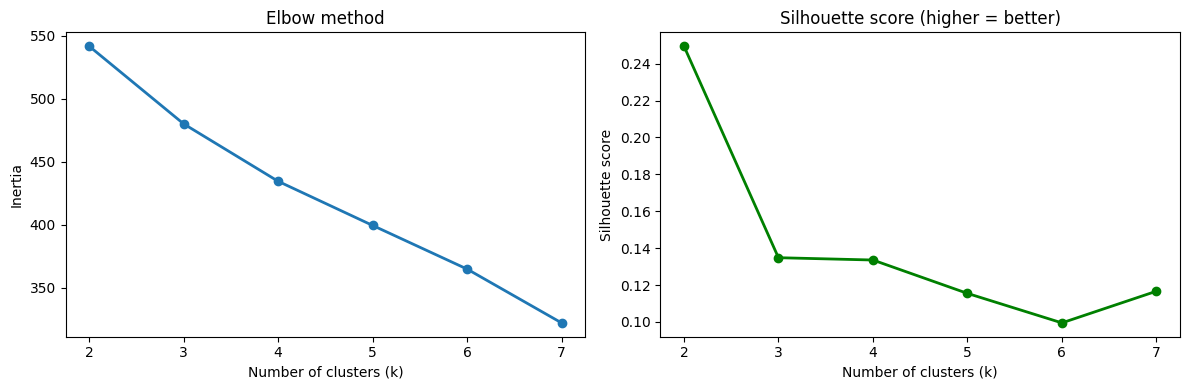


Best k = 2  (silhouette = 0.250)

Cluster centers (original scale):
   total_spend  avg_txn_amount  txn_count  weekend_spend_pct  high_spend_days
0       2005.9          1804.9        1.3                0.1              0.9
1      45750.8          1618.7       28.3                0.3              2.6

Persona distribution:
persona
Balanced Spender     11
Saver                 9
Impulsive Spender     6
Name: count, dtype: int64
PCA explained variance: 37.0%


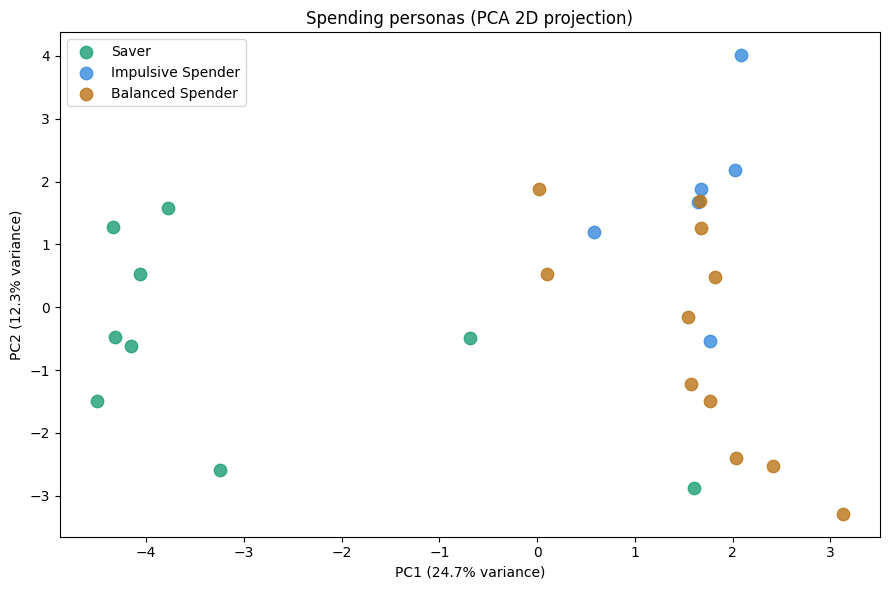

Models saved to backend/models/


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
import joblib
warnings.filterwarnings("ignore")

df = pd.read_csv("../data/clean_transactions.csv", parse_dates=["date"])
expenses = df[df["txn_type"] == "debit"].copy()

print(f"Working with {len(expenses):,} expense transactions")
print(f"Date range: {expenses['date'].min().date()} to {expenses['date'].max().date()}")

# If you have a single user's data, aggregate by month
# This gives you one row per month to cluster on
monthly_profile = (
    expenses
    .groupby(expenses["date"].dt.to_period("M"))
    .agg(
        total_spend        = ("amount", "sum"),
        avg_txn_amount     = ("amount", "mean"),
        txn_count          = ("amount", "count"),
        max_single_txn     = ("amount", "max"),
        weekend_spend_pct  = ("is_weekend", "mean"),
        high_spend_days    = ("is_high_spend_day", "sum"),
        unique_categories  = ("category", "nunique"),
    )
    .reset_index()
)

# Add per-category spend ratios — these are the most powerful clustering features
cat_monthly = (
    expenses
    .groupby([expenses["date"].dt.to_period("M"), "category"])["amount"]
    .sum()
    .unstack(fill_value=0)
)
# Convert to % of total spend that month (ratios cluster better than raw amounts)
cat_ratios = cat_monthly.div(cat_monthly.sum(axis=1), axis=0)
cat_ratios.columns = [f"pct_{c.lower().replace(' ','_').replace('/','_').replace('&','and')}"
                      for c in cat_ratios.columns]
cat_ratios = cat_ratios.reset_index()

profile = monthly_profile.merge(cat_ratios, on="date")
profile["date_str"] = profile["date"].astype(str)
profile = profile.set_index("date_str")

print(f"Profile matrix: {profile.shape}")
print(profile.head())

# Drop the period column before scaling
X = profile.drop(columns=["date"]).fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Try k from 2 to 7
k_range   = range(2, 8)
inertias  = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    print(f"  k={k}  inertia={km.inertia_:.0f}  silhouette={silhouette_score(X_scaled, labels):.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(list(k_range), inertias, marker="o", linewidth=2)
ax1.set_title("Elbow method")
ax1.set_xlabel("Number of clusters (k)")
ax1.set_ylabel("Inertia")

ax2.plot(list(k_range), sil_scores, marker="o", linewidth=2, color="green")
ax2.set_title("Silhouette score (higher = better)")
ax2.set_xlabel("Number of clusters (k)")
ax2.set_ylabel("Silhouette score")

plt.tight_layout()
plt.savefig("../data/charts/elbow_silhouette.png", dpi=150)
plt.show()

# Pick the k with highest silhouette score
best_k = list(k_range)[sil_scores.index(max(sil_scores))]
print(f"\nBest k = {best_k}  (silhouette = {max(sil_scores):.3f})")

# Fit with best k
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
profile["cluster"] = km_final.fit_predict(X_scaled)

# Inspect cluster centers — this tells you what each cluster means
centers = pd.DataFrame(
    scaler.inverse_transform(km_final.cluster_centers_),
    columns=X.columns
)
print("\nCluster centers (original scale):")
print(centers[["total_spend", "avg_txn_amount", "txn_count",
               "weekend_spend_pct", "high_spend_days"]].round(1))

# Manually assign persona labels based on what you see in the centers
# Adjust these to match what your data actually shows
def label_cluster(row):
    if row["total_spend"] < centers["total_spend"].median():
        return "Saver"
    elif row["high_spend_days"] > centers["high_spend_days"].median() * 1.5:
        return "Impulsive Spender"
    elif row["unique_categories"] >= centers["unique_categories"].median():
        return "Balanced Spender"
    else:
        return "Category-Heavy Spender"

profile["persona"] = profile.apply(label_cluster, axis=1)

print("\nPersona distribution:")
print(profile["persona"].value_counts())

# Save the labeled profile
profile.to_csv("../data/monthly_profiles.csv")

# Reduce to 2D for plotting
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.1%}")

plt.figure(figsize=(9, 6))
colors = ["#1D9E75", "#378ADD", "#BA7517", "#D85A30"]
for i, persona in enumerate(profile["persona"].unique()):
    mask = profile["persona"] == persona
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                label=persona, s=80, alpha=0.8, color=colors[i % len(colors)])

plt.title("Spending personas (PCA 2D projection)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.legend()
plt.tight_layout()
plt.savefig("../data/charts/persona_clusters.png", dpi=150)
plt.show()

# Save models for the backend 
joblib.dump(km_final, "../backend/models/kmeans_model.pkl")
joblib.dump(scaler,   "../backend/models/scaler.pkl")
joblib.dump(pca,      "../backend/models/pca.pkl")
print("Models saved to backend/models/")